---
# DNN : `spam` (sélection de la meilleur architecture)
---

## Packages

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras import callbacks, layers, models

import matplotlib.pyplot as plt

2025-10-02 08:43:59.808204: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-02 08:43:59.890196: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-02 08:44:01.759531: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## 1. Données
---

### 1.1. Importation

In [2]:
# En local :
directory = 'data/'

# Sur Google collab ou Onyxia (sur un répertoire temporaire) :
# directory = ''

# Sur Google collab (sur le drive) :
# from google.colab import drive
# drive.mount('/content/drive')
# directory = '/content/drive/MyDrive/Data/'

In [3]:
data = pd.read_csv(directory + 'spam.csv',
                   header    = 0,
                   # index_col = 0,
                   sep       = ',',
                   decimal   = '.')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [5]:
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_leftbrac,char_freq_leftsquarebrac,char_freq_exclaim,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### 1.2. Gestion des données manquantes

In [6]:
missing_percentage = data.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
No


### 1.3. Gestion des variables

In [7]:
target = 'spam'

y = data[target]
X = data.drop(target, axis=1)

### 1.4. Création des échantillons de validation et test

In [8]:
test_portion  = 1/5
valid_portion = 1/5

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (2944, 57)
Dimensions de X_valid : (736, 57)
Dimensions de X_test  : (921, 57)
Dimensions de y_train : (2944,)
Dimensions de y_valid : (736,)
Dimensions de y_test  : (921,)


### 1.5. Normalisation des covariables

On normalise (centrage-réduction) les covariables :

In [9]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_norm = scaler.transform(X_train)
X_valid_norm = scaler.transform(X_valid)
X_test_norm  = scaler.transform(X_test)

---
## 2. DNN
---

In [10]:
# Définir différentes architectures à tester
architectures = [
    {'n_units_hl1': 50, 'n_units_hl2': 30, 'dropout_hl1': 0.2, 'dropout_hl2': 0.2},
    {'n_units_hl1': 64, 'n_units_hl2': 32, 'dropout_hl1': 0.3, 'dropout_hl2': 0.3},
    {'n_units_hl1': 32, 'n_units_hl2': 16, 'dropout_hl1': 0.1, 'dropout_hl2': 0.1},
    {'n_units_hl1': 100, 'n_units_hl2': 50, 'dropout_hl1': 0.4, 'dropout_hl2': 0.4}
]

results = []

for i, arch in enumerate(architectures):
    model = models.Sequential(name=f'DNN_{i}')
    model.add(layers.Input(shape=(X_train_norm.shape[1],), name='Inputs'))
    model.add(layers.Dense(units=arch['n_units_hl1'], activation='relu', name='Hidden_layer_1'))
    model.add(layers.Dropout(rate=arch['dropout_hl1'], name='Dropout_Hidden_layer_1'))
    model.add(layers.Dense(units=arch['n_units_hl2'], activation='relu', name='Hidden_layer_2'))
    model.add(layers.Dropout(rate=arch['dropout_hl2'], name='Dropout_Hidden_layer_2'))
    model.add(layers.Dense(units=1, activation='sigmoid', name='Output_layer'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    callback = callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=20, restore_best_weights=True)
    hist = model.fit(X_train_norm, y_train, batch_size=500, epochs=200,
                     validation_data=(X_valid_norm, y_valid), callbacks=[callback], verbose=0)
    score = model.evaluate(X_valid_norm, y_valid, verbose=0)
    results.append({'arch': arch, 'val_loss': score[0], 'val_acc': score[1], 'model': model})
    print(f"Architecture {i+1}/{len(architectures)} évaluée : Val Loss = {score[0]:.4f}, Val Acc = {score[1]:.4f}")

# Sélection du meilleur modèle selon la loss de validation
best = min(results, key=lambda x: x['val_loss'])
print("Meilleure architecture :", best['arch'])
print(f"Validation loss: {best['val_loss']:.4f}, Validation accuracy: {best['val_acc']:.4f}")

# Utiliser le meilleur modèle pour la suite
model = best['model']

2025-10-02 08:44:02.696210: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Architecture 1/4 évaluée : Val Loss = 0.2414, Val Acc = 0.9307
Architecture 2/4 évaluée : Val Loss = 0.2219, Val Acc = 0.9280
Architecture 3/4 évaluée : Val Loss = 0.2174, Val Acc = 0.9239
Architecture 4/4 évaluée : Val Loss = 0.2217, Val Acc = 0.9293
Meilleure architecture : {'n_units_hl1': 32, 'n_units_hl2': 16, 'dropout_hl1': 0.1, 'dropout_hl2': 0.1}
Validation loss: 0.2174, Validation accuracy: 0.9239


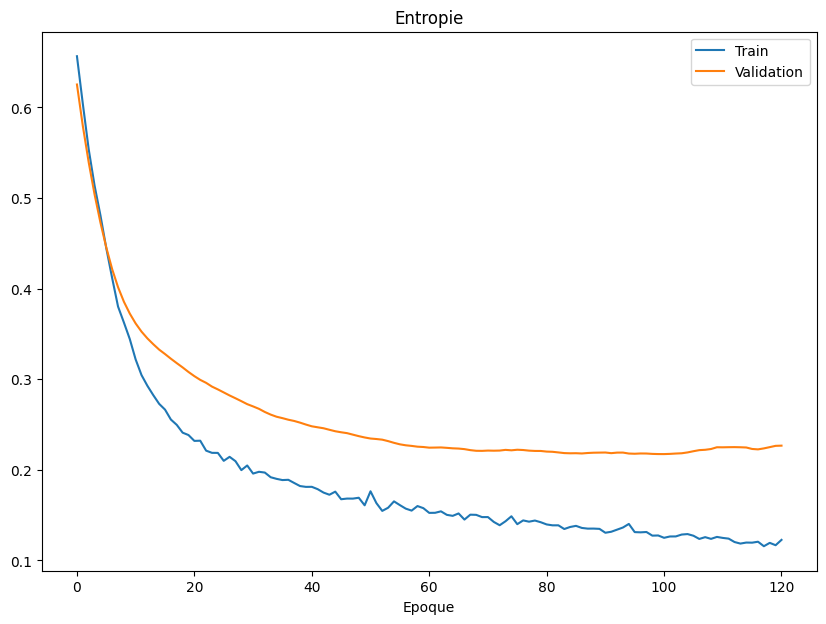

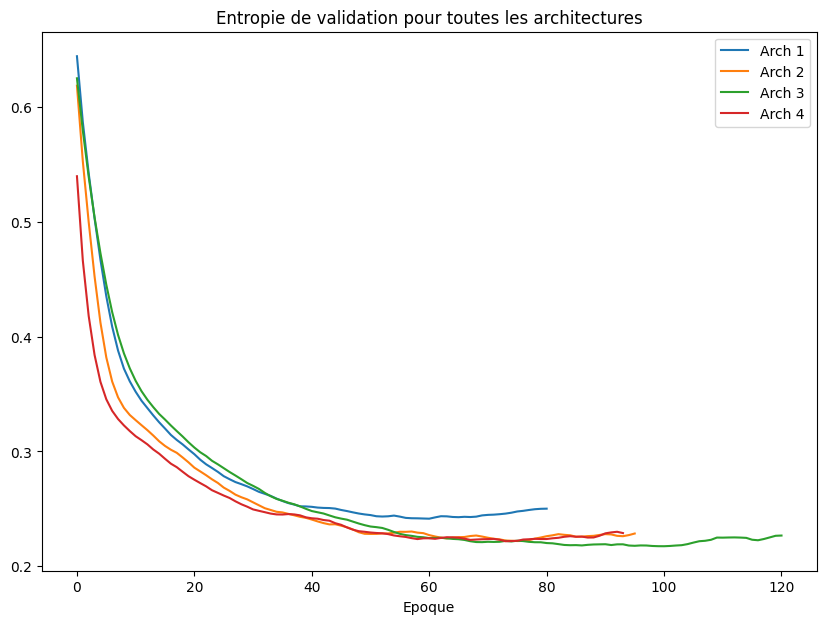

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(model.history.history['loss'], label='Train')
ax.plot(model.history.history['val_loss'], label='Validation')
ax.set_xlabel('Epoque')
ax.set_title('Entropie')
ax.legend(loc='best')
plt.show()

# plot all models
fig, ax = plt.subplots(figsize=(10, 7))
for i, res in enumerate(results):
    ax.plot(res['model'].history.history['val_loss'], label=f"Arch {i+1}")
ax.set_xlabel('Epoque')
ax.set_title('Entropie de validation pour toutes les architectures')
ax.legend(loc='best')
plt.show()